In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from data_preparation import ConvectiveAdjustmentDataset
import plotting
from sklearn.neighbors import NearestNeighbors
import models
import omegaconf
import os
import glob


# Can Baselines Compositionally Generalise? 

This is a notebook to work though the models and data in a quick feedback approach to try and answer the question above. We hope to work from the ground up, introducing a model at a time where each model should be better than the previous ... .

Lets start by loading the data 

Train dataset size: 2100, input: torch.Size([2, 4]), target: torch.Size([4])
In-domain test dataset size: 900, input: torch.Size([2, 4]), target: torch.Size([4])
Composition val dataset size: 500, input: torch.Size([2, 4]), target: torch.Size([4])
Composition test dataset size: 500, input: torch.Size([2, 4]), target: torch.Size([4])
OOD test dataset size: 1000, input: torch.Size([2, 4]), target: torch.Size([4])


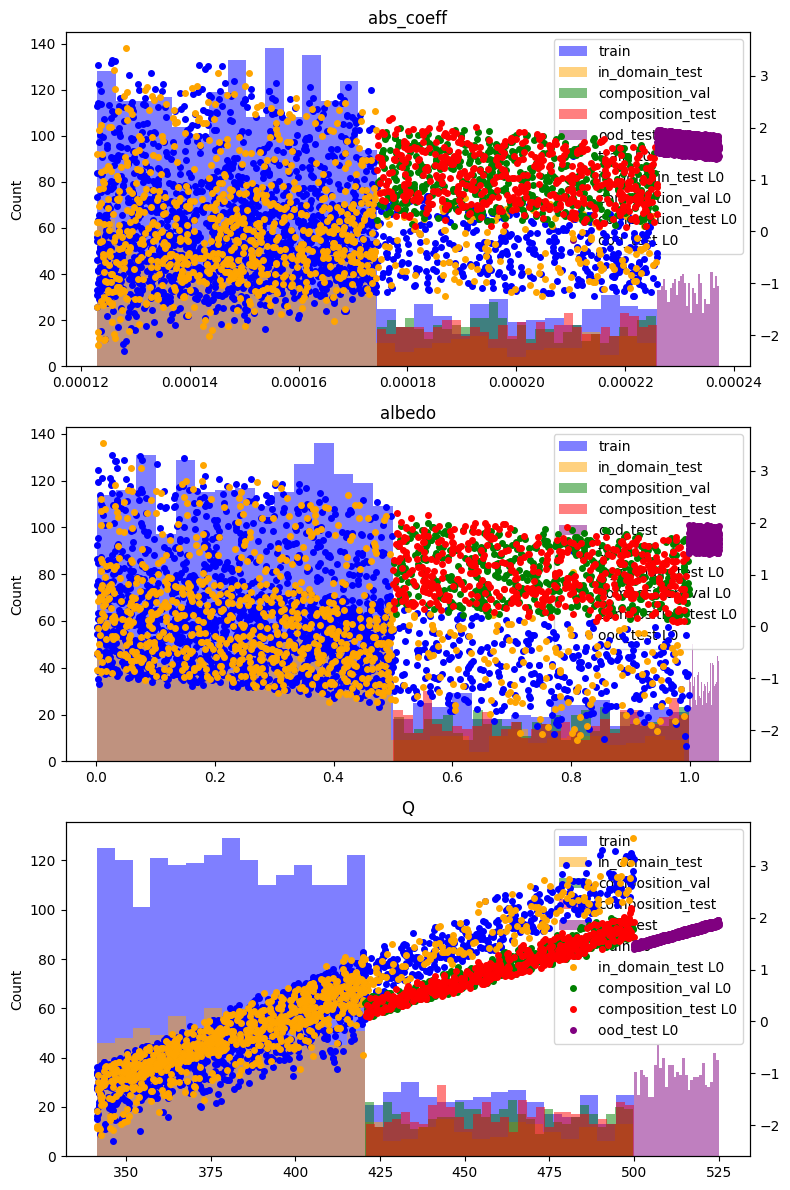

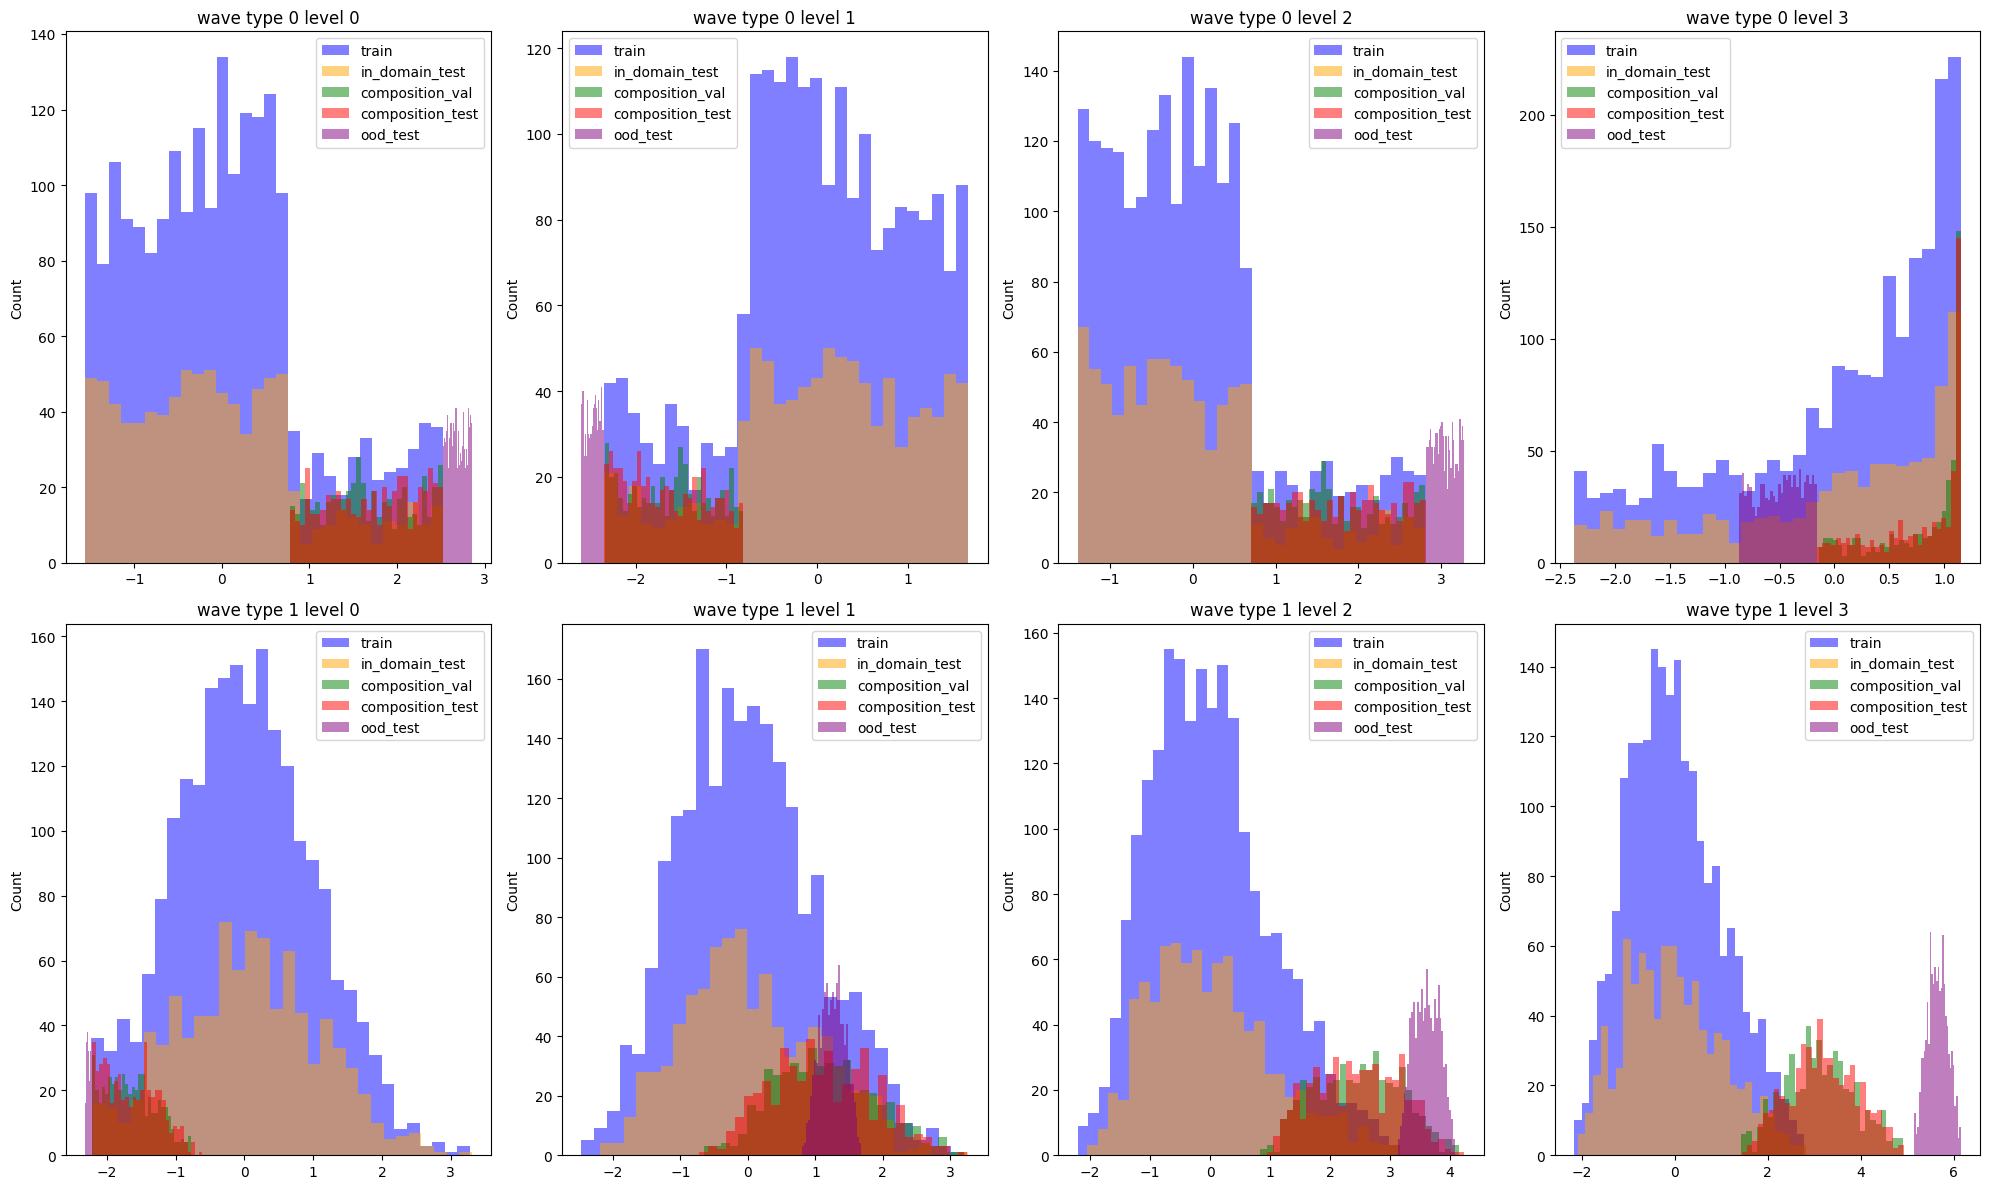

In [22]:
dataset_cfg_path = "../config/dataset/convective_adjustment.yaml"
dataset_cfg = omegaconf.OmegaConf.load(dataset_cfg_path)
dataset_testing_type = "quick"

train_dataset = ConvectiveAdjustmentDataset(
    dataset_mode="train",
    dataset_type="in_domain",
    dataset_testing_type=dataset_testing_type,
    dataset_cfg=dataset_cfg,
)
print(
    f"Train dataset size: {len(train_dataset)}, input: {train_dataset[0][0].shape}, target: {train_dataset[0][1].shape}"
)
normalisation_stats = train_dataset.normalisation_stats

in_domain_test_dataset = ConvectiveAdjustmentDataset(
    dataset_mode="test",
    dataset_type="in_domain",
    dataset_testing_type=dataset_testing_type,
    dataset_cfg=dataset_cfg,
    normalisation_stats=normalisation_stats,
)
print(
    f"In-domain test dataset size: {len(in_domain_test_dataset)}, input: {in_domain_test_dataset[0][0].shape}, target: {in_domain_test_dataset[0][1].shape}"
)
composition_val_dataset = ConvectiveAdjustmentDataset(
    dataset_mode="val",
    dataset_type="composition",
    dataset_testing_type=dataset_testing_type,
    dataset_cfg=dataset_cfg,
    normalisation_stats=normalisation_stats,
)
print(
    f"Composition val dataset size: {len(composition_val_dataset)}, input: {composition_val_dataset[0][0].shape}, target: {composition_val_dataset[0][1].shape}"
)
composition_test_dataset = ConvectiveAdjustmentDataset(
    dataset_mode="test",
    dataset_type="composition",
    dataset_testing_type=dataset_testing_type,
    dataset_cfg=dataset_cfg,
    normalisation_stats=normalisation_stats,
)
print(
    f"Composition test dataset size: {len(composition_test_dataset)}, input: {composition_test_dataset[0][0].shape}, target: {composition_test_dataset[0][1].shape}"
)
ood_test_dataset = ConvectiveAdjustmentDataset(
    dataset_mode="test",
    dataset_type="ood",
    dataset_testing_type=dataset_testing_type,
    dataset_cfg=dataset_cfg,
    normalisation_stats=normalisation_stats,
)
print(
    f"OOD test dataset size: {len(ood_test_dataset)}, input: {ood_test_dataset[0][0].shape}, target: {ood_test_dataset[0][1].shape}"
)

datasets = {
    "train": train_dataset,
    "in_domain_test": in_domain_test_dataset,
    "composition_val": composition_val_dataset,
    "composition_test": composition_test_dataset,
    "ood_test": ood_test_dataset,
}

plotting.plot_convective_adjustment_dataset_factors_with_outputs(
    datasets=datasets
)
plotting.plot_convective_adjustment_dataset_inputs(
    datasets=datasets
)



We start with one of the most basic: `predict_mean`

In [23]:
train_mean = train_dataset.target.mean(axis=0)

predict_mean_results = {}
mse_loss = torch.nn.MSELoss()
for name, dataset in datasets.items():
    dataset_len = len(dataset)
    train_mean_expanded = train_mean.expand(dataset_len, -1)
    mse = mse_loss(train_mean_expanded, dataset.target)
    print(f"{name}: {mse:.6f}")
    predict_mean_results[name] = mse.item()


train: 0.992079
in_domain_test: 1.059037
composition_val: 3.446192
composition_test: 3.560027
ood_test: 9.680770


Next, at the other end is the lookup table approach `nearby_lookup`

In [24]:

def nearby_lookup(train_dataset, test_dataset):
    train_input = train_dataset.input.flatten(start_dim=1).numpy()
    test_input = test_dataset.input.flatten(start_dim=1).numpy()
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(train_input)
    distances, indices = nbrs.kneighbors(test_input)
    predictions = train_dataset.target[indices]
    return predictions

predict_nearby_results = {}
for name, dataset in datasets.items():
    predictions = nearby_lookup(train_dataset, dataset)
    mse = mse_loss(predictions.squeeze(), dataset.target)
    print(f"{name} nearby lookup MSE: {mse:.6f}")
    predict_nearby_results[name] = mse.item()


train nearby lookup MSE: 0.000000
in_domain_test nearby lookup MSE: 0.014734
composition_val nearby lookup MSE: 0.516361
composition_test nearby lookup MSE: 0.542506
ood_test nearby lookup MSE: 3.354722


Ok great, so far both models show the expected ood effect, with nearest neighbour performing better. Next we try more DL approaches, starting with basic MLP

In [25]:
def load_multiseed_single_model(repository_path, model_name, seed, dataset_cfg, normalisation_stats):
    """
    Loads a single model from a repository given the model name and seed.
    """
    checkpoint_pattern = os.path.join(repository_path, f"{model_name}_{seed}_*.ckpt")

    checkpoint_paths = glob.glob(checkpoint_pattern)
    config_path = os.path.join(repository_path, f"run_config_{seed}.yaml")

    model_cfg = omegaconf.OmegaConf.load(config_path)

    model = models.load_model_from_checkpoint(checkpoint_path=checkpoint_paths[0], model_name=model_name, model_params=model_cfg, data_params=dataset_cfg, normalisation_stats=normalisation_stats)

    return model

def get_multi_seed_results(repository_path, model_name, seeds, datasets, dataset_cfg, normalisation_stats):
    multi_seed_results = {name: [] for name in datasets.keys()}

    for seed in seeds:
        model = load_multiseed_single_model(repository_path, model_name, seed, dataset_cfg, normalisation_stats)
        model.eval()
        with torch.no_grad():
            for name, dataset in datasets.items():
                dataloader = torch.utils.data.DataLoader(dataset, batch_size=2048, shuffle=False)
                all_predictions = []
                for batch in dataloader:
                    x, y = batch
                    with torch.no_grad():
                        x = x.flatten(start_dim=1)
                        output = model(x)
                    all_predictions.append(output)
                all_predictions = torch.cat(all_predictions, dim=0)
                mse = mse_loss(all_predictions, dataset.target)
                multi_seed_results[name].append(mse.item())
                
                print(f"Model: {model_name}, Seed: {seed}, Dataset: {name}, MSE: {mse:.6f}")

    return multi_seed_results



In [26]:
repository_path = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.4/12/testing/functional_test/2026-01-12-17-01-35/mlp_lr_0.01'
model_name = "mlp"
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
multi_seed_results = get_multi_seed_results(repository_path, model_name, seeds, datasets, dataset_cfg, normalisation_stats)
print(f'Multi-seed means: { {name: np.mean(results) for name, results in multi_seed_results.items()} }, multi_seed_std_dev: { {name: np.std(results) for name, results in multi_seed_results.items()} }')


Model: mlp, Seed: 0, Dataset: train, MSE: 0.000120
Model: mlp, Seed: 0, Dataset: in_domain_test, MSE: 0.000127
Model: mlp, Seed: 0, Dataset: composition_val, MSE: 0.000398
Model: mlp, Seed: 0, Dataset: composition_test, MSE: 0.000419
Model: mlp, Seed: 0, Dataset: ood_test, MSE: 0.001926
Model: mlp, Seed: 1, Dataset: train, MSE: 0.000115
Model: mlp, Seed: 1, Dataset: in_domain_test, MSE: 0.000123
Model: mlp, Seed: 1, Dataset: composition_val, MSE: 0.000201
Model: mlp, Seed: 1, Dataset: composition_test, MSE: 0.000216
Model: mlp, Seed: 1, Dataset: ood_test, MSE: 0.002030
Model: mlp, Seed: 2, Dataset: train, MSE: 0.000131
Model: mlp, Seed: 2, Dataset: in_domain_test, MSE: 0.000136
Model: mlp, Seed: 2, Dataset: composition_val, MSE: 0.000473
Model: mlp, Seed: 2, Dataset: composition_test, MSE: 0.000501
Model: mlp, Seed: 2, Dataset: ood_test, MSE: 0.001629
Model: mlp, Seed: 3, Dataset: train, MSE: 0.000122
Model: mlp, Seed: 3, Dataset: in_domain_test, MSE: 0.000128
Model: mlp, Seed: 3, Data

In [27]:

mlp_model_path = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.4/12/testing/functional_test/2026-01-12-16-34-27/mlp_lr_0.01'
mlp_model_checkpoint_path = os.path.join(mlp_model_path, 'mlp_None_2026-01-12-16-34-27.ckpt')
mlp_model_cfg_path = os.path.join(mlp_model_path, 'run_config.yaml')

mlp_model_cfg = omegaconf.OmegaConf.load(mlp_model_cfg_path)

mlp_model = models.load_model_from_checkpoint(checkpoint_path=mlp_model_checkpoint_path, model_name='mlp', model_params=mlp_model_cfg, data_params=dataset_cfg, normalisation_stats=normalisation_stats)

predict_mlp_results = {}
for name, dataset in datasets.items():
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=2048, shuffle=False)
    all_predictions = []
    for batch in dataloader:
        x, y = batch
        with torch.no_grad():
            x = x.flatten(start_dim=1)
            output = mlp_model(x)
        all_predictions.append(output)
    all_predictions_tensor = torch.cat(all_predictions, dim=0)
    mse = mse_loss(all_predictions_tensor, dataset.target)
    print(f"{name} MLP model MSE: {mse:.8f}")
    predict_mlp_results[name] = mse.item()


train MLP model MSE: 0.00011984
in_domain_test MLP model MSE: 0.00012699
composition_val MLP model MSE: 0.00039762
composition_test MLP model MSE: 0.00041867
ood_test MLP model MSE: 0.00192574
